# Distance Bias and Composite Motif Detection

This tutorial covers detecting and analyzing fixed-distance binding patterns:
- Detecting patterns with fixed-distance binding bias using {func}`~tfmindi.tl.detect_distance_bias`
- Visualizing distance bias with profile and heatmap plots
- Extending seqlets to capture composite motifs using {func}`~tfmindi.tl.extend_biased_seqlets`
- Re-clustering extended seqlets to identify dimers and multimers

In [1]:
import tfmindi as tm
import numpy as np

%matplotlib inline

DATA_DIR = "../../../../data/tfmindi/"  # change to your project's data directory

In [2]:
# Load clustered data from previous tutorial
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

## What is distance bias?

Distance bias occurs when transcription factor binding sites show a preference to occur at fixed distances from each other. 
For example, the SOX10-TF has a commonly occuring dimer motif that binds cooperatively, yet, seqlet calling will most likely have detected this as two separate seqlets.   

TF-MInDi can detect these patterns by analyzing contribution score profiles around identified binding sites and finding consistent peaks at fixed distances.

## Creating Patterns

First, we need to create consensus patterns for each cluster as before using {func}`~tfmindi.tl.create_patterns`.  
For distance bias detection, we recommend using the `"kmer"` method, which provides more precise pattern locations without extending beyond the actual seqlet boundaries compared to tomtom.  
Also, it's important here to not subsample when creating the pattern, since only the seqlets that were used in creating a {class}`~tfmindi.Pattern` object will be considered for detecting distance bias.  

In [3]:
patterns = tm.tl.create_patterns(adata, method="kmer")

Creating patterns for 63 clusters...


## Detecting Distance Bias

Now we can detect distance bias for each pattern using {func}`~tfmindi.tl.detect_distance_bias`.  

This function:
1. Extracts contribution scores in a window around each Seqlet from a Pattern instance
2. Aligns and averages these scores across all instances per Pattern
3. Detects peaks in the averaged profile that indicate nearby binding sites

Key parameters:
- `window`: How many basepairs up/downstream to analyze  
- `height`: Peak height threshold in the z-scored profile 

The function returns a {class}`~tfmindi.BiasDetectionResult` object containing the profile, detected peaks, and methods for further analysis.

In [4]:
# Detect distance bias for all patterns
results = {k: tm.tl.detect_distance_bias(adata, pattern, window=20) for k, pattern in patterns.items()}

In [5]:
# Check which patterns show a detected distance bias
patterns_with_bias = {k: r for k, r in results.items() if r.has_bias}
print(f"Found {len(patterns_with_bias)} patterns with distance bias out of {len(results)} total patterns")

Found 2 patterns with distance bias out of 63 total patterns


## Visualizing Distance Bias

TF-MInDi provides two plotting functions to visualize distance bias patterns:
- {func}`~tfmindi.pl.distance_bias_profile`: Line plot showing averaged contribution profile
- {func}`~tfmindi.pl.distance_bias_heatmap`: Heatmap of individual instances sorted by peak position

Both plots mark the pattern location (red) and detected peaks (orange).

### Profile Plot

The profile plot shows the averaged z-scored contribution across all instances of a pattern.  
Red lines mark the pattern location, orange lines mark detected peaks indicating nearby binding sites.

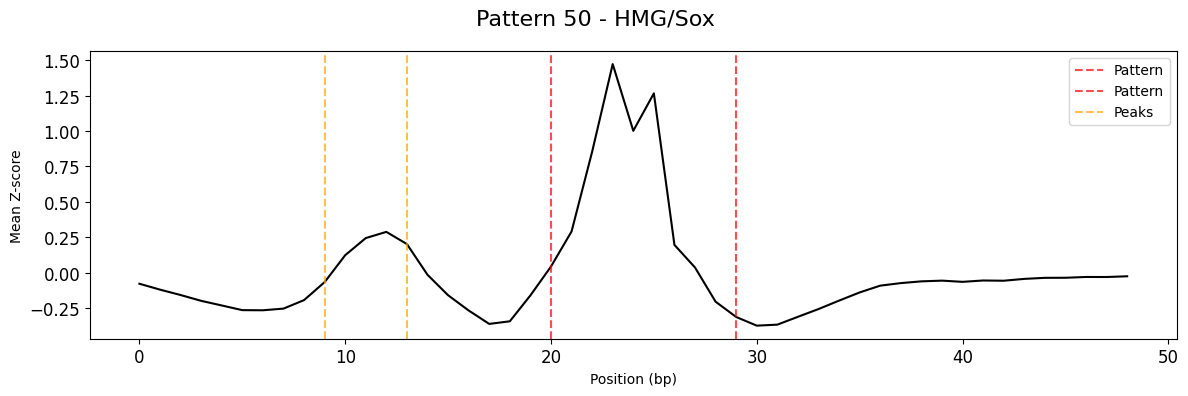

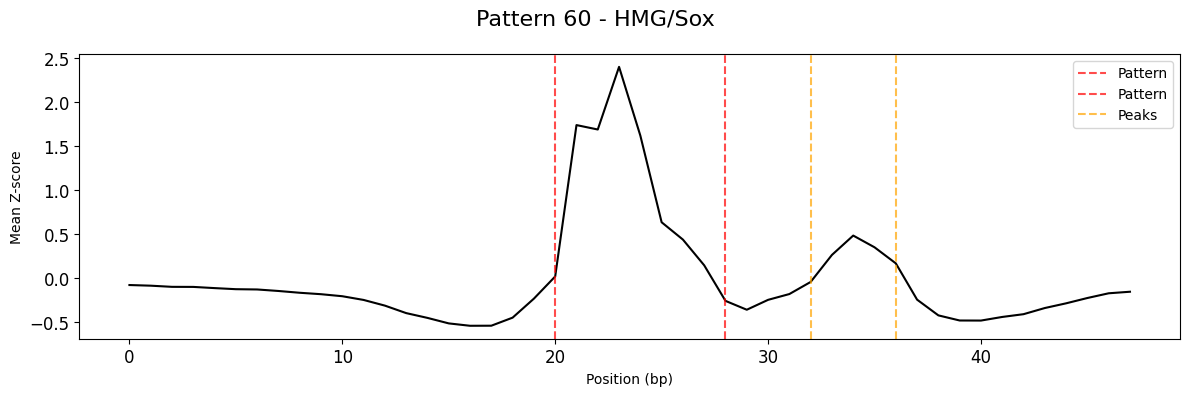

In [7]:
# Visualize both patterns with detected distance bias
for pattern_id in list(patterns_with_bias.keys()):
    result = results[pattern_id]
    tm.pl.distance_bias_profile(result, title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}", width=12, height=4)

### Heatmap Plot

The heatmap shows individual seqlet instances (rows) sorted by their maximum contribution position.  
This visualization helps identify consistent vs. variable distance bias patterns.

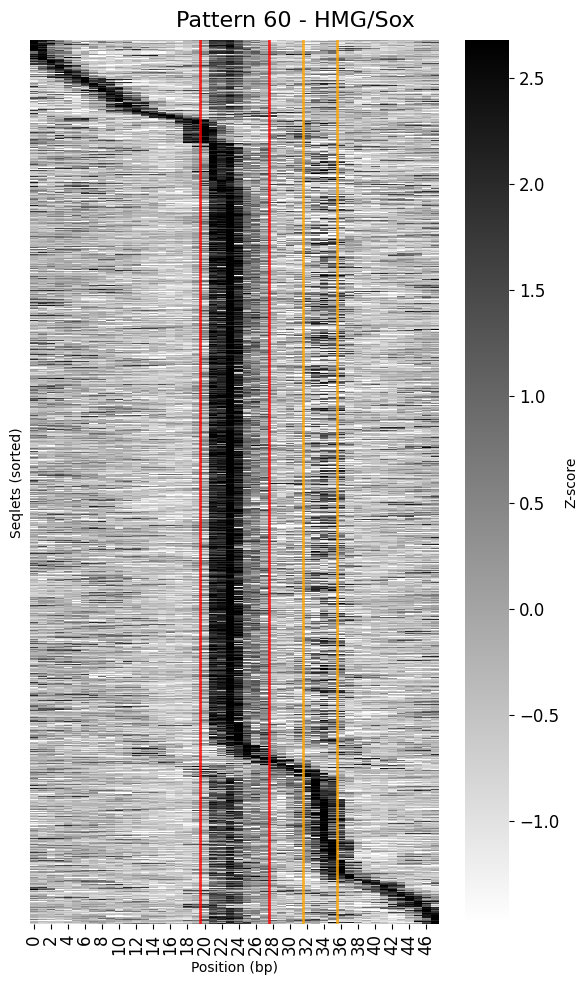

In [8]:
tm.pl.distance_bias_heatmap(result, title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}", x_label_rotation=90)

In [43]:
patterns["60"].ic_trim(0.4)

(np.int64(0), np.int64(7))

In [ ]:
above_values = np.where(patterns["60"].ic() > 0)

(array([0, 1, 2, 3, 4, 5, 6, 7]),)

In [40]:
patterns["60"].ic()

array([0.32818285, 1.63857175, 1.32412399, 1.76654311, 1.23764508,
       0.60796746, 0.83146482, 0.39243756])

In [42]:
np.where(np.diff(patterns["60"].ic() > 0.4))[0]

array([0, 6])

In [27]:
np.where(np.diff((patterns["60"].ic() > 0.0) * 1))[0]

array([], dtype=int64)

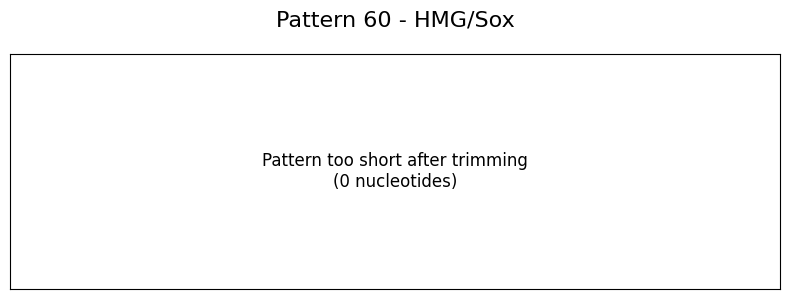

In [24]:
tm.pl.pattern_logo(
    patterns[pattern_id],
    title=f"Pattern {pattern_id} - {patterns[pattern_id].dbd}",
    ic_threshold=0.0,
    min_nucleotides=0,
)

## Inspecting Detection Results

The {class}`~tfmindi.BiasDetectionResult` object provides useful properties and methods:

In [ ]:
# Pick a pattern to inspect
pattern_id = "50"  # Sox/HMG pattern example
result = results[pattern_id]

print(f"Pattern {pattern_id} - {patterns[pattern_id].dbd}")
print(f"Has distance bias: {result.has_bias}")

if result.has_bias:
    print(f"Number of peaks detected: {len(result.peak_windows)}")
    print(f"Extension distances (upstream, downstream): {result.extension_distances}")

    # Get seqlets showing distance bias
    biased_seqlets = result.get_biased_seqlets(threshold=0.5)
    print(f"Seqlets with distance bias (threshold=0.5): {len(biased_seqlets)}/{len(patterns[pattern_id].seqlets)}")

## Extending Seqlets to Capture Composite Motifs

Once we've identified patterns with distance bias, we can extend the seqlets to capture the full composite motif using {func}`~tfmindi.tl.extend_biased_seqlets`.

This function:
1. Extends seqlets based on detected peak locations
2. Removes overlapping seqlets to avoid redundancy
3. Returns new seqlet coordinates and contribution matrices

Key parameters:
- `threshold`: Z-score threshold for identifying seqlets with distance bias (default: 1.0)
- `extra_flanks`: Additional basepairs to add beyond detected peaks (default: 7bp)
- `overlap_fraction_new/old`: Overlap thresholds for removing redundant seqlets (default: 0.7)

In [ ]:
# Extend seqlets for patterns showing distance bias
results_with_bias = [r for r in results.values() if r.has_bias]

new_seqlets_df, new_seqlet_matrices = tm.tl.extend_biased_seqlets(
    adata, results_with_bias, threshold=1.0, extra_flanks=7
)

In [ ]:
# Check the results
print(f"Original number of seqlets: {len(adata.obs)}")
print(f"New number of seqlets: {len(new_seqlets_df)}")

## Re-clustering with Extended Seqlets

Now we can create a new AnnData object with the extended seqlets and re-run the full analysis pipeline.  
This will allow us to identify composite motif patterns that weren't captured in the initial clustering.

In [ ]:
# Calculate motif similarity for extended seqlets
# Note: this step can take a while depending on the number of seqlets
sim_matrix_extended = tm.pp.calculate_motif_similarity(
    new_seqlet_matrices,
    adata.var["motif_ppm"].to_dict(),  # reuse motif collection from adata
    chunk_size=50000,
    n_nearest=100,
)

In [ ]:
# Create new AnnData with extended seqlets
adata_extended = tm.pp.create_seqlet_adata(
    sim_matrix_extended,
    new_seqlets_df,
    seqlet_matrices=new_seqlet_matrices,
    oh_sequences=adata.uns["unique_examples"]["oh"],
    contrib_scores=adata.uns["unique_examples"]["contrib"],
    motif_collection=adata.var["motif_ppm"].to_dict(),
    motif_annotations=adata.var[
        ["Direct_annot", "Motif_similarity_annot", "Orthology_annot", "Motif_similarity_and_Orthology_annot"]
    ],
    motif_to_dbd=adata.var["dbd"].to_dict(),
)

In [ ]:
# Cluster the extended seqlets
tm.tl.cluster_seqlets(adata_extended, resolution=3.0)

In [ ]:
# Compare DBD distributions before and after extension
print("Original DBD distribution:")
print(adata.obs["cluster_dbd"].value_counts().head(10))
print("\nExtended seqlets DBD distribution:")
print(adata_extended.obs["cluster_dbd"].value_counts().head(10))

## Visualizing Extended Patterns

Let's create patterns from the extended seqlets and visualize them to see the captured composite motifs.

In [ ]:
# Create patterns from extended seqlets
patterns_extended = tm.tl.create_patterns(adata_extended, method="kmer")

In [ ]:
# Visualize extended patterns on t-SNE
tm.pl.tsne_logos(
    adata_extended,
    patterns_extended,
    gray_background=True,
    min_nucleotides=4,
    width=12,
    height=12,
    s=0.3,
    alpha=0.01,
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.2,
    min_seqlets=10,
)

In [ ]:
# Save extended seqlets for further analysis
tm.save_h5ad(adata_extended, DATA_DIR + "seqlets_extended_dimers.h5ad")

## Summary

In this tutorial, we:
1. Detected distance bias patterns using `detect_distance_bias()`
2. Visualized distance bias with profile and heatmap plots
3. Extended seqlets to capture composite motifs using `extend_biased_seqlets()`
4. Re-clustered extended seqlets to identify dimer/multimer patterns

This workflow is particularly useful for:
- Identifying homodimers and heterodimers
- Discovering composite regulatory elements
- Understanding TF spacing constraints
- Improving motif annotations for complex binding modes

The extended seqlets can be used for all downstream analyses just like regular seqlets, including topic modeling and region annotation.